In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [2]:
!pip install -q SimpleITK pandas matplotlib numpy torch torchvision segmentation-models-pytorch scikit-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.8 MB/s eta 0:00:00


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [5]:
%%writefile src/uncertainty.py
import torch
import torch.nn as nn


def enable_dropout_only(model):

    model.eval()

    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            module.train()

    return model


def mc_dropout_predict(model, inputs, n_samples=20):

    model = enable_dropout_only(model)

    predictions = []

    with torch.no_grad():
        for _ in range(n_samples):
            pred = model(inputs)
            predictions.append(pred.unsqueeze(0))

    predictions = torch.cat(predictions, dim=0)

    mean_prediction = predictions.mean(dim=0)
    std_prediction = predictions.std(dim=0)

    return mean_prediction, std_prediction, predictions

Writing src/uncertainty.py


In [6]:
from src.dataset import SynthRAD2p5DDataset
from src.model import build_unetplusplus_resnet34
from src.metrics import calculate_all_metrics, denormalize_to_hu
from src.uncertainty import mc_dropout_predict

df = pd.read_csv("data/patient_list.csv")

with open("splits/fold_0.json", "r") as f:
    split = json.load(f)

val_dataset = SynthRAD2p5DDataset(
    dataframe=df,
    patient_ids=split["val"],
    input_slices=7,
    image_size=320,
    min_hu=-1000,
    max_hu=1600,
    max_patients=20
)

model = build_unetplusplus_resnet34(
    in_channels=7,
    out_channels=1,
    encoder_weights=None,
    dropout=0.2
).to(device)

checkpoint_path = "checkpoints/final_single_fold/best_fold0.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded:", checkpoint_path)
print("Best epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint["val_loss"])
print("Validation samples:", len(val_dataset))

Loaded: checkpoints/final_single_fold/best_fold0.pth
Best epoch: 12
Best val loss: 0.20581862263948586
Validation samples: 1524


In [7]:
sample = val_dataset[50]

inputs = sample["input"].unsqueeze(0).to(device)
targets = sample["target"].unsqueeze(0).to(device)
masks = sample["mask"].unsqueeze(0).to(device)

mean_pred, std_pred, all_preds = mc_dropout_predict(
    model=model,
    inputs=inputs,
    n_samples=20
)

print("Input shape:", inputs.shape)
print("Mean prediction shape:", mean_pred.shape)
print("Uncertainty/std shape:", std_pred.shape)
print("All predictions shape:", all_preds.shape)

Input shape: torch.Size([1, 7, 320, 320])
Mean prediction shape: torch.Size([1, 1, 320, 320])
Uncertainty/std shape: torch.Size([1, 1, 320, 320])
All predictions shape: torch.Size([20, 1, 1, 320, 320])


In [8]:
input_center = inputs[0, 3].cpu().numpy()
target_slice = targets[0, 0].cpu().numpy()
mean_slice = mean_pred[0, 0].cpu().numpy()
std_slice = std_pred[0, 0].cpu().numpy()
mask_slice = masks[0, 0].cpu().numpy()

input_hu = denormalize_to_hu(input_center)
target_hu = denormalize_to_hu(target_slice)
mean_hu = denormalize_to_hu(mean_slice)

error_hu = np.abs(mean_hu - target_hu)


uncertainty_hu = std_slice * ((1600 - (-1000)) / 2)

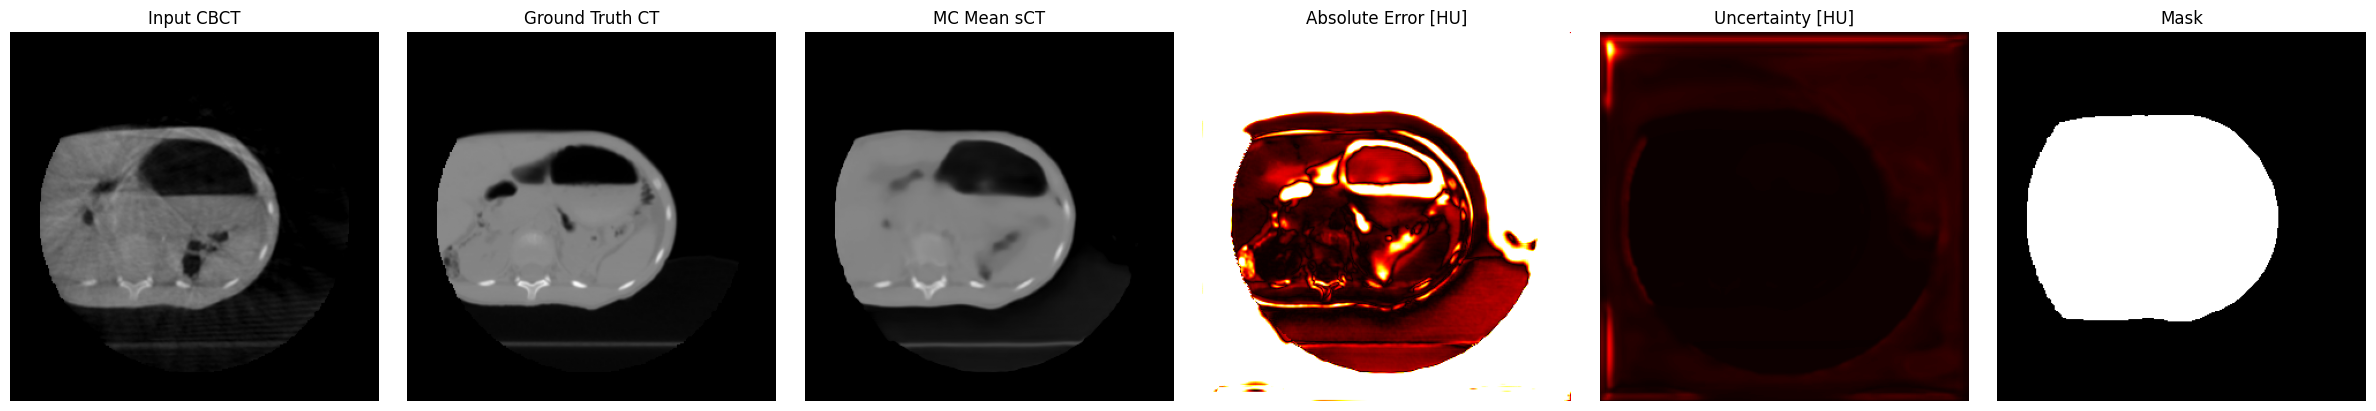

In [9]:
os.makedirs("results/figures/uncertainty", exist_ok=True)

plt.figure(figsize=(24, 4))

plt.subplot(1, 6, 1)
plt.imshow(input_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Input CBCT")
plt.axis("off")

plt.subplot(1, 6, 2)
plt.imshow(target_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Ground Truth CT")
plt.axis("off")

plt.subplot(1, 6, 3)
plt.imshow(mean_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("MC Mean sCT")
plt.axis("off")

plt.subplot(1, 6, 4)
plt.imshow(error_hu, cmap="hot", vmin=0, vmax=500)
plt.title("Absolute Error [HU]")
plt.axis("off")

plt.subplot(1, 6, 5)
plt.imshow(uncertainty_hu, cmap="hot")
plt.title("Uncertainty [HU]")
plt.axis("off")

plt.subplot(1, 6, 6)
plt.imshow(mask_slice, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/figures/uncertainty/mc_dropout_example.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
mask_bool = mask_slice > 0

error_values = error_hu[mask_bool].flatten()
uncertainty_values = uncertainty_hu[mask_bool].flatten()

corr = np.corrcoef(error_values, uncertainty_values)[0, 1]

print("Error-uncertainty correlation:", corr)
print("Mean uncertainty inside body [HU]:", uncertainty_values.mean())
print("Mean error inside body [HU]:", error_values.mean())

Error-uncertainty correlation: 0.14704873714854874
Mean uncertainty inside body [HU]: 47.822742
Mean error inside body [HU]: 104.66259


In [11]:
all_uncertainty_metrics = []

n_mc_samples = 20
max_samples = 100

model.eval()

for i in tqdm(range(min(max_samples, len(val_dataset)))):
    sample = val_dataset[i]

    inputs = sample["input"].unsqueeze(0).to(device)
    targets = sample["target"].unsqueeze(0).to(device)
    masks = sample["mask"].unsqueeze(0).to(device)

    mean_pred, std_pred, _ = mc_dropout_predict(
        model=model,
        inputs=inputs,
        n_samples=n_mc_samples
    )

    input_center = inputs[0, 3].cpu().numpy()
    target_slice = targets[0, 0].cpu().numpy()
    mean_slice = mean_pred[0, 0].cpu().numpy()
    std_slice = std_pred[0, 0].cpu().numpy()
    mask_slice = masks[0, 0].cpu().numpy()

    input_hu = denormalize_to_hu(input_center)
    target_hu = denormalize_to_hu(target_slice)
    mean_hu = denormalize_to_hu(mean_slice)

    error_hu = np.abs(mean_hu - target_hu)
    uncertainty_hu = std_slice * ((1600 - (-1000)) / 2)

    mask_bool = mask_slice > 0

    error_values = error_hu[mask_bool].flatten()
    uncertainty_values = uncertainty_hu[mask_bool].flatten()

    if len(error_values) > 2 and np.std(uncertainty_values) > 0:
        corr = np.corrcoef(error_values, uncertainty_values)[0, 1]
    else:
        corr = np.nan

    metrics = calculate_all_metrics(
        pred_norm=mean_slice,
        target_norm=target_slice,
        input_norm=input_center,
        mask=mask_slice,
        min_hu=-1000,
        max_hu=1600
    )

    metrics["sample_index"] = i
    metrics["patient_id"] = sample["patient_id"]
    metrics["slice_index"] = int(sample["slice_index"])
    metrics["mean_uncertainty_hu"] = uncertainty_values.mean()
    metrics["std_uncertainty_hu"] = uncertainty_values.std()
    metrics["mean_error_hu"] = error_values.mean()
    metrics["error_uncertainty_corr"] = corr

    all_uncertainty_metrics.append(metrics)

uncertainty_df = pd.DataFrame(all_uncertainty_metrics)

os.makedirs("results/metrics", exist_ok=True)
uncertainty_df.to_csv("results/metrics/mc_dropout_uncertainty_metrics_100slices.csv", index=False)

uncertainty_df.head()

100%|██████████| 100/100 [00:37<00:00,  2.69it/s]


,sct_mae_hu,sct_rmse_hu,sct_psnr,sct_ssim,raw_cbct_mae_hu,raw_cbct_rmse_hu,raw_cbct_psnr,raw_cbct_ssim,sct_mae_air_lung_hu,raw_cbct_mae_air_lung_hu,...,raw_cbct_mae_bone_hu,sct_mae_body_hu,raw_cbct_mae_body_hu,sample_index,patient_id,slice_index,mean_uncertainty_hu,std_uncertainty_hu,mean_error_hu,error_uncertainty_corr
0,119.853325,197.389252,22.392998,0.284861,134.806808,210.962479,21.815365,0.809854,205.212433,224.422073,...,204.646393,119.853325,134.806808,0,2ABA006,6,56.116196,79.537537,119.853325,0.067142
1,118.329956,198.997375,22.322521,0.300932,134.722763,225.015656,21.255211,0.838413,218.995056,239.180161,...,191.291168,118.329956,134.722763,1,2ABA006,7,44.911995,53.670097,118.329956,0.101166
2,113.734360,199.269836,22.310637,0.305207,134.311356,231.728653,20.999872,0.826761,223.296783,229.552017,...,184.288040,113.734360,134.311356,2,2ABA006,8,46.764370,54.993092,113.734360,0.110799
3,106.315971,190.579300,22.697954,0.303424,132.732239,222.441833,21.355137,0.823233,204.369202,219.898834,...,170.173721,106.315971,132.732239,3,2ABA006,9,59.799618,64.230385,106.315971,0.064205
4,111.288239,203.607559,22.123589,0.296322,137.752563,228.942841,21.104927,0.812477,207.654968,231.350449,...,175.413712,111.288239,137.752563,4,2ABA006,10,59.284775,70.688850,111.288239,0.015150


In [12]:
uncertainty_summary = uncertainty_df[
    [
        "sct_mae_hu",
        "raw_cbct_mae_hu",
        "sct_rmse_hu",
        "sct_psnr",
        "sct_ssim",
        "mean_uncertainty_hu",
        "std_uncertainty_hu",
        "mean_error_hu",
        "error_uncertainty_corr"
    ]
].agg(["mean", "std"]).T

uncertainty_summary.to_csv("results/metrics/mc_dropout_uncertainty_summary.csv")

uncertainty_summary

,mean,std
sct_mae_hu,112.361641,42.623741
raw_cbct_mae_hu,189.401016,33.292622
sct_rmse_hu,206.635315,64.043045
sct_psnr,22.386229,2.594270
sct_ssim,0.310633,0.037222
mean_uncertainty_hu,42.288769,12.739137
std_uncertainty_hu,52.771568,11.792760
mean_error_hu,112.361641,42.623741
error_uncertainty_corr,0.100687,0.133194


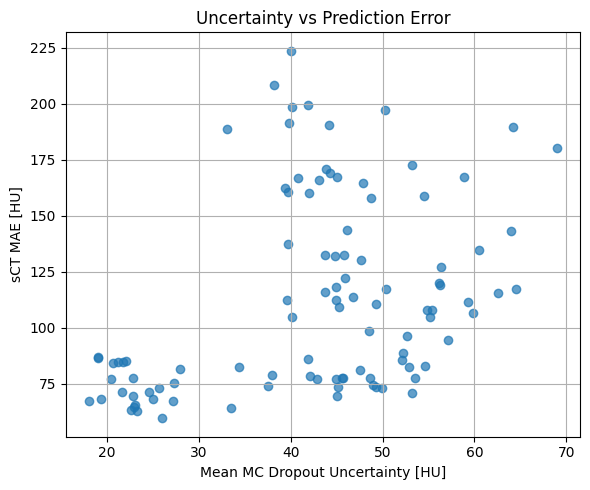

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(
    uncertainty_df["mean_uncertainty_hu"],
    uncertainty_df["sct_mae_hu"],
    alpha=0.7
)
plt.xlabel("Mean MC Dropout Uncertainty [HU]")
plt.ylabel("sCT MAE [HU]")
plt.title("Uncertainty vs Prediction Error")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/figures/uncertainty/uncertainty_vs_error_scatter.png", dpi=200)
plt.show()

In [14]:
high_uncertainty_cases = uncertainty_df.sort_values(
    "mean_uncertainty_hu",
    ascending=False
).head(5)

high_uncertainty_cases[
    [
        "sample_index",
        "patient_id",
        "slice_index",
        "sct_mae_hu",
        "mean_uncertainty_hu",
        "error_uncertainty_corr"
    ]
]

,sample_index,patient_id,slice_index,sct_mae_hu,mean_uncertainty_hu,error_uncertainty_corr
36,36,2ABA006,42,180.092422,68.936775,0.220063
6,6,2ABA006,12,117.296867,64.481674,0.006992
35,35,2ABA006,41,189.673126,64.188873,0.210369
39,39,2ABA006,45,143.205383,63.982128,0.069401
48,48,2ABA006,54,115.478241,62.588139,0.111851


Most uncertain sample index: 36


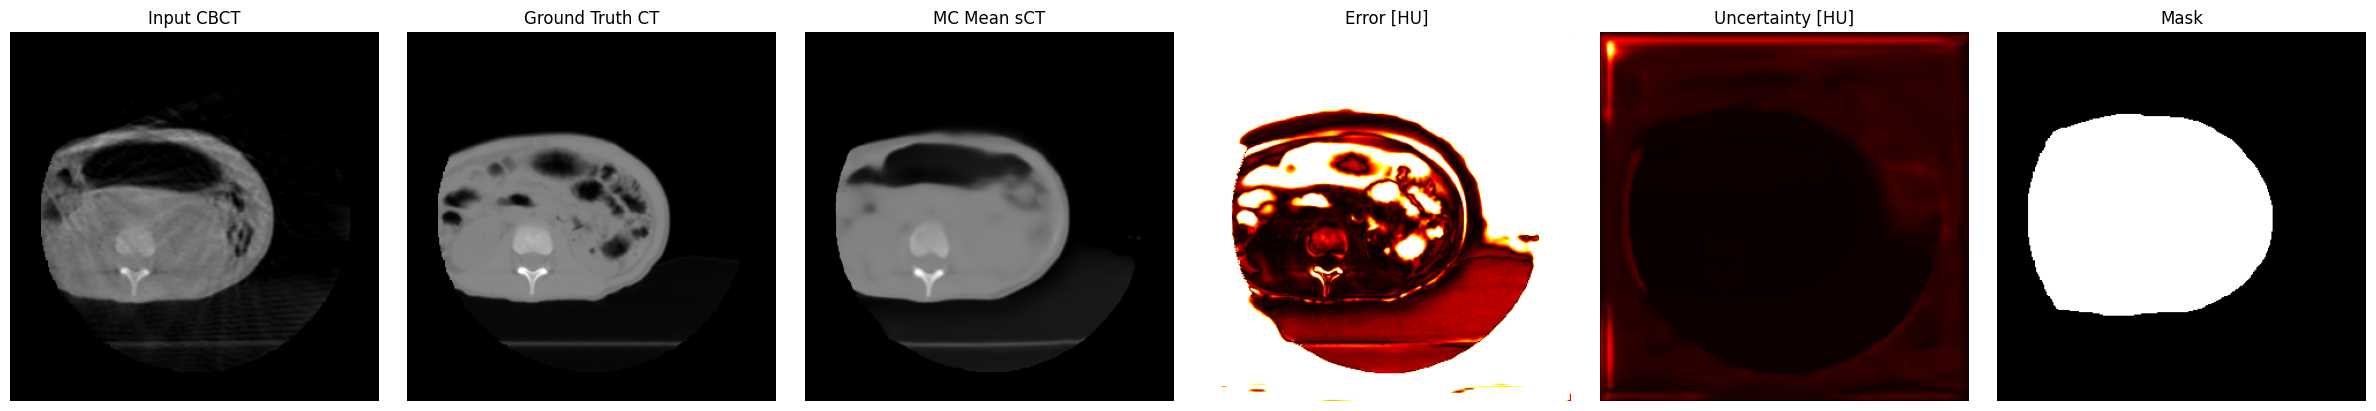

In [15]:
most_uncertain_idx = int(high_uncertainty_cases.iloc[0]["sample_index"])
print("Most uncertain sample index:", most_uncertain_idx)

sample = val_dataset[most_uncertain_idx]

inputs = sample["input"].unsqueeze(0).to(device)
targets = sample["target"].unsqueeze(0).to(device)
masks = sample["mask"].unsqueeze(0).to(device)

mean_pred, std_pred, _ = mc_dropout_predict(
    model=model,
    inputs=inputs,
    n_samples=20
)

input_center = inputs[0, 3].cpu().numpy()
target_slice = targets[0, 0].cpu().numpy()
mean_slice = mean_pred[0, 0].cpu().numpy()
std_slice = std_pred[0, 0].cpu().numpy()
mask_slice = masks[0, 0].cpu().numpy()

input_hu = denormalize_to_hu(input_center)
target_hu = denormalize_to_hu(target_slice)
mean_hu = denormalize_to_hu(mean_slice)
error_hu = np.abs(mean_hu - target_hu)
uncertainty_hu = std_slice * 1300.0

plt.figure(figsize=(24, 4))

plt.subplot(1, 6, 1)
plt.imshow(input_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Input CBCT")
plt.axis("off")

plt.subplot(1, 6, 2)
plt.imshow(target_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Ground Truth CT")
plt.axis("off")

plt.subplot(1, 6, 3)
plt.imshow(mean_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("MC Mean sCT")
plt.axis("off")

plt.subplot(1, 6, 4)
plt.imshow(error_hu, cmap="hot", vmin=0, vmax=500)
plt.title("Error [HU]")
plt.axis("off")

plt.subplot(1, 6, 5)
plt.imshow(uncertainty_hu, cmap="hot")
plt.title("Uncertainty [HU]")
plt.axis("off")

plt.subplot(1, 6, 6)
plt.imshow(mask_slice, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/figures/uncertainty/most_uncertain_case.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
with open("project_notes.txt", "a") as f:
    f.write("\n\nDay 17 - Monte Carlo dropout uncertainty\n")
    f.write("Implemented MC dropout uncertainty estimation using dropout active during inference.\n")
    f.write("Generated mean sCT prediction and voxel-wise uncertainty maps.\n")
    f.write("Evaluated uncertainty over 100 validation slices using 20 stochastic forward passes per slice.\n")
    f.write("Saved uncertainty metrics, example figures, and uncertainty-vs-error scatter plot.\n")

Random-100 MC Dropout Check


In [17]:
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

num_random_samples = min(100, len(val_dataset))

random_indices = random.sample(
    range(len(val_dataset)),
    k=num_random_samples
)

print("Number of random samples:", len(random_indices))
print("First 10 random indices:", random_indices[:10])

Number of random samples: 100
First 10 random indices: [1309, 228, 51, 1518, 563, 501, 457, 285, 1508, 209]


In [18]:
random_uncertainty_metrics = []

n_mc_samples = 20

model.eval()

for sample_counter, dataset_index in enumerate(tqdm(random_indices)):
    sample = val_dataset[dataset_index]

    inputs = sample["input"].unsqueeze(0).to(device)
    targets = sample["target"].unsqueeze(0).to(device)
    masks = sample["mask"].unsqueeze(0).to(device)

    mean_pred, std_pred, _ = mc_dropout_predict(
        model=model,
        inputs=inputs,
        n_samples=n_mc_samples
    )

    input_center = inputs[0, 3].cpu().numpy()
    target_slice = targets[0, 0].cpu().numpy()
    mean_slice = mean_pred[0, 0].cpu().numpy()
    std_slice = std_pred[0, 0].cpu().numpy()
    mask_slice = masks[0, 0].cpu().numpy()

    input_hu = denormalize_to_hu(input_center)
    target_hu = denormalize_to_hu(target_slice)
    mean_hu = denormalize_to_hu(mean_slice)

    error_hu = np.abs(mean_hu - target_hu)

    # normalized [-1,1] std converted to HU:
    # HU range = 2600, so half range = 1300
    uncertainty_hu = std_slice * 1300.0

    mask_bool = mask_slice > 0

    error_values = error_hu[mask_bool].flatten()
    uncertainty_values = uncertainty_hu[mask_bool].flatten()

    if len(error_values) > 2 and np.std(uncertainty_values) > 0:
        corr = np.corrcoef(error_values, uncertainty_values)[0, 1]
    else:
        corr = np.nan

    metrics = calculate_all_metrics(
        pred_norm=mean_slice,
        target_norm=target_slice,
        input_norm=input_center,
        mask=mask_slice,
        min_hu=-1000,
        max_hu=1600
    )

    metrics["sample_counter"] = sample_counter
    metrics["dataset_index"] = dataset_index
    metrics["patient_id"] = sample["patient_id"]
    metrics["slice_index"] = int(sample["slice_index"])
    metrics["mean_uncertainty_hu"] = uncertainty_values.mean()
    metrics["std_uncertainty_hu"] = uncertainty_values.std()
    metrics["mean_error_hu"] = error_values.mean()
    metrics["error_uncertainty_corr"] = corr

    random_uncertainty_metrics.append(metrics)

random_uncertainty_df = pd.DataFrame(random_uncertainty_metrics)

random_uncertainty_df.to_csv(
    "results/metrics/mc_dropout_uncertainty_metrics_random100.csv",
    index=False
)

random_uncertainty_df.head()

100%|██████████| 100/100 [00:39<00:00,  2.51it/s]


,sct_mae_hu,sct_rmse_hu,sct_psnr,sct_ssim,raw_cbct_mae_hu,raw_cbct_rmse_hu,raw_cbct_psnr,raw_cbct_ssim,sct_mae_air_lung_hu,raw_cbct_mae_air_lung_hu,...,sct_mae_body_hu,raw_cbct_mae_body_hu,sample_counter,dataset_index,patient_id,slice_index,mean_uncertainty_hu,std_uncertainty_hu,mean_error_hu,error_uncertainty_corr
0,127.851151,208.471054,21.918552,0.358999,113.358871,226.232727,21.208359,0.881852,187.754242,169.254257,...,127.851151,113.358871,0,1309,2ABA128,17,57.017414,50.336105,127.851151,0.116224
1,60.390923,123.511490,26.465321,0.313044,292.863281,322.064636,18.140606,0.602111,131.241226,103.720375,...,60.390923,292.863281,1,228,2ABA030,82,36.575081,47.297039,60.390923,0.190469
2,100.377060,179.965591,23.195679,0.318943,195.363739,272.944458,19.577982,0.667468,154.789017,147.351578,...,100.377060,195.363739,2,51,2ABA006,57,59.374413,71.764603,100.377060,0.235182
3,131.468643,232.892792,20.956347,0.252759,250.974091,279.509064,19.371550,0.385987,302.406647,160.395248,...,131.468643,250.974091,3,1518,2ABA132,75,35.595547,48.784378,131.468643,0.024578
4,67.832542,131.494446,25.921318,0.256485,255.194504,297.324677,18.834848,0.650411,55.279247,77.386314,...,67.832542,255.194504,4,563,2ABA068,26,32.356014,49.940880,67.832542,0.265168


In [19]:
random_uncertainty_summary = random_uncertainty_df[
    [
        "sct_mae_hu",
        "raw_cbct_mae_hu",
        "sct_rmse_hu",
        "sct_psnr",
        "sct_ssim",
        "mean_uncertainty_hu",
        "std_uncertainty_hu",
        "mean_error_hu",
        "error_uncertainty_corr"
    ]
].agg(["mean", "std"]).T

random_uncertainty_summary.to_csv(
    "results/metrics/mc_dropout_uncertainty_summary_random100.csv"
)

random_uncertainty_summary

,mean,std
sct_mae_hu,97.216774,32.131527
raw_cbct_mae_hu,193.735214,72.044167
sct_rmse_hu,183.418930,55.922581
sct_psnr,23.393902,2.487464
sct_ssim,0.314663,0.050668
mean_uncertainty_hu,41.808418,15.526765
std_uncertainty_hu,50.849010,12.510624
mean_error_hu,97.216774,32.131527
error_uncertainty_corr,0.147143,0.139860


In [20]:
patient_counts = random_uncertainty_df["patient_id"].value_counts()

print("Number of unique patients:", random_uncertainty_df["patient_id"].nunique())
patient_counts.head(20)

Number of unique patients: 20


,count
patient_id,
2ABA030,9
2ABA128,8
2ABA130,8
2ABA056,8
2ABA075,7
2ABA132,6
2ABA068,6
2ABA006,5
2ABA044,5


In [21]:
patient_counts.to_csv("results/metrics/mc_dropout_random100_patient_counts.csv")

In [22]:
first100_summary = pd.read_csv(
    "results/metrics/mc_dropout_uncertainty_summary.csv",
    index_col=0
)

random100_summary = pd.read_csv(
    "results/metrics/mc_dropout_uncertainty_summary_random100.csv",
    index_col=0
)

comparison_uncertainty = pd.DataFrame({
    "first100_mean": first100_summary["mean"],
    "random100_mean": random100_summary["mean"],
    "difference_random_minus_first": random100_summary["mean"] - first100_summary["mean"]
})

comparison_uncertainty.to_csv(
    "results/metrics/mc_dropout_first100_vs_random100_comparison.csv"
)

comparison_uncertainty

,first100_mean,random100_mean,difference_random_minus_first
sct_mae_hu,112.361641,97.216774,-15.144867
raw_cbct_mae_hu,189.401016,193.735214,4.334198
sct_rmse_hu,206.635315,183.418930,-23.216385
sct_psnr,22.386229,23.393902,1.007673
sct_ssim,0.310633,0.314663,0.004030
mean_uncertainty_hu,42.288769,41.808418,-0.480350
std_uncertainty_hu,52.771568,50.849010,-1.922558
mean_error_hu,112.361641,97.216774,-15.144867
error_uncertainty_corr,0.100687,0.147143,0.046455


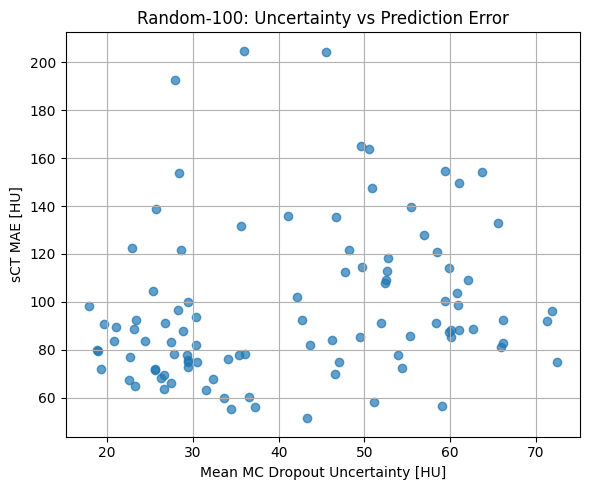

In [23]:
import os
import matplotlib.pyplot as plt

os.makedirs("results/figures/uncertainty", exist_ok=True)

plt.figure(figsize=(6, 5))
plt.scatter(
    random_uncertainty_df["mean_uncertainty_hu"],
    random_uncertainty_df["sct_mae_hu"],
    alpha=0.7
)
plt.xlabel("Mean MC Dropout Uncertainty [HU]")
plt.ylabel("sCT MAE [HU]")
plt.title("Random-100: Uncertainty vs Prediction Error")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "results/figures/uncertainty/random100_uncertainty_vs_error_scatter.png",
    dpi=200
)
plt.show()

In [24]:
high_uncertainty_random = random_uncertainty_df.sort_values(
    "mean_uncertainty_hu",
    ascending=False
).head(5)

high_uncertainty_random[
    [
        "dataset_index",
        "patient_id",
        "slice_index",
        "sct_mae_hu",
        "mean_uncertainty_hu",
        "error_uncertainty_corr"
    ]
]

,dataset_index,patient_id,slice_index,sct_mae_hu,mean_uncertainty_hu,error_uncertainty_corr
39,318,2ABA044,21,74.892807,72.431427,0.358410
51,940,2ABA096,27,96.104881,71.864044,0.069215
90,946,2ABA096,33,91.839989,71.293289,0.172968
48,541,2ABA064,81,92.406197,66.231110,-0.057656
63,1442,2ABA130,75,83.002449,66.140335,0.143382


In [25]:
high_uncertainty_random.to_csv(
    "results/metrics/mc_dropout_random100_high_uncertainty_cases.csv",
    index=False
)

Most uncertain dataset index: 318


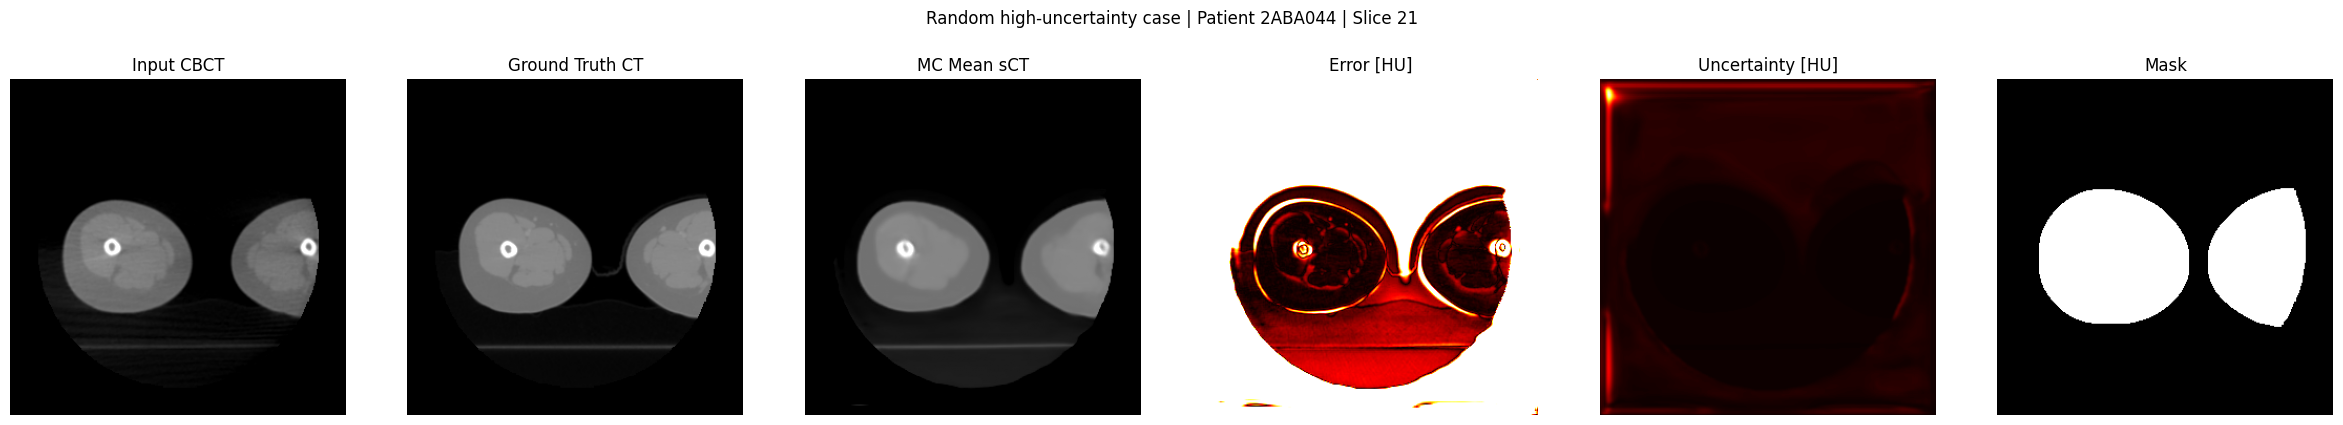

In [26]:
most_uncertain_dataset_index = int(high_uncertainty_random.iloc[0]["dataset_index"])
print("Most uncertain dataset index:", most_uncertain_dataset_index)

sample = val_dataset[most_uncertain_dataset_index]

inputs = sample["input"].unsqueeze(0).to(device)
targets = sample["target"].unsqueeze(0).to(device)
masks = sample["mask"].unsqueeze(0).to(device)

mean_pred, std_pred, _ = mc_dropout_predict(
    model=model,
    inputs=inputs,
    n_samples=20
)

input_center = inputs[0, 3].cpu().numpy()
target_slice = targets[0, 0].cpu().numpy()
mean_slice = mean_pred[0, 0].cpu().numpy()
std_slice = std_pred[0, 0].cpu().numpy()
mask_slice = masks[0, 0].cpu().numpy()

input_hu = denormalize_to_hu(input_center)
target_hu = denormalize_to_hu(target_slice)
mean_hu = denormalize_to_hu(mean_slice)

error_hu = np.abs(mean_hu - target_hu)
uncertainty_hu = std_slice * 1300.0

plt.figure(figsize=(24, 4))

plt.subplot(1, 6, 1)
plt.imshow(input_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Input CBCT")
plt.axis("off")

plt.subplot(1, 6, 2)
plt.imshow(target_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Ground Truth CT")
plt.axis("off")

plt.subplot(1, 6, 3)
plt.imshow(mean_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("MC Mean sCT")
plt.axis("off")

plt.subplot(1, 6, 4)
plt.imshow(error_hu, cmap="hot", vmin=0, vmax=500)
plt.title("Error [HU]")
plt.axis("off")

plt.subplot(1, 6, 5)
plt.imshow(uncertainty_hu, cmap="hot")
plt.title("Uncertainty [HU]")
plt.axis("off")

plt.subplot(1, 6, 6)
plt.imshow(mask_slice, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.suptitle(
    f"Random high-uncertainty case | Patient {sample['patient_id']} | Slice {sample['slice_index']}",
    y=1.05
)

plt.tight_layout()
plt.savefig(
    "results/figures/uncertainty/random100_most_uncertain_case.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [27]:
highest_error_random = random_uncertainty_df.sort_values(
    "sct_mae_hu",
    ascending=False
).head(5)

highest_error_random[
    [
        "dataset_index",
        "patient_id",
        "slice_index",
        "sct_mae_hu",
        "mean_uncertainty_hu",
        "error_uncertainty_corr"
    ]
]

,dataset_index,patient_id,slice_index,sct_mae_hu,mean_uncertainty_hu,error_uncertainty_corr
27,1330,2ABA128,38,204.820312,35.915985,0.005835
82,1327,2ABA128,35,204.338058,45.489895,0.000554
38,696,2ABA075,7,192.571564,27.962086,-0.013641
14,1209,2ABA114,69,165.099609,49.615833,-0.028859
32,1206,2ABA114,66,163.756027,50.518795,-0.011435


In [28]:
highest_error_random.to_csv(
    "results/metrics/mc_dropout_random100_highest_error_cases.csv",
    index=False
)

Highest-error dataset index: 1330


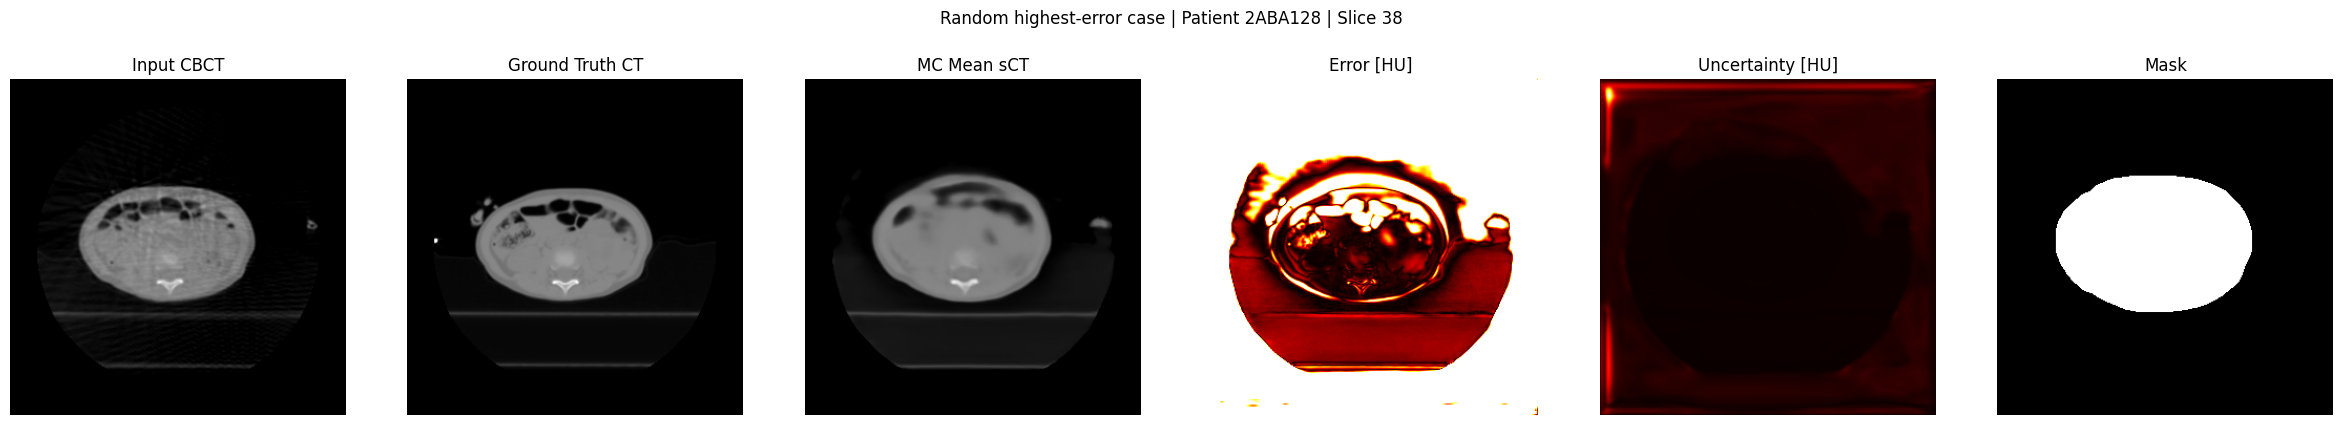

In [29]:
highest_error_dataset_index = int(highest_error_random.iloc[0]["dataset_index"])
print("Highest-error dataset index:", highest_error_dataset_index)

sample = val_dataset[highest_error_dataset_index]

inputs = sample["input"].unsqueeze(0).to(device)
targets = sample["target"].unsqueeze(0).to(device)
masks = sample["mask"].unsqueeze(0).to(device)

mean_pred, std_pred, _ = mc_dropout_predict(
    model=model,
    inputs=inputs,
    n_samples=20
)

input_center = inputs[0, 3].cpu().numpy()
target_slice = targets[0, 0].cpu().numpy()
mean_slice = mean_pred[0, 0].cpu().numpy()
std_slice = std_pred[0, 0].cpu().numpy()
mask_slice = masks[0, 0].cpu().numpy()

input_hu = denormalize_to_hu(input_center)
target_hu = denormalize_to_hu(target_slice)
mean_hu = denormalize_to_hu(mean_slice)

error_hu = np.abs(mean_hu - target_hu)
uncertainty_hu = std_slice * 1300.0

plt.figure(figsize=(24, 4))

plt.subplot(1, 6, 1)
plt.imshow(input_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Input CBCT")
plt.axis("off")

plt.subplot(1, 6, 2)
plt.imshow(target_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("Ground Truth CT")
plt.axis("off")

plt.subplot(1, 6, 3)
plt.imshow(mean_hu, cmap="gray", vmin=-1000, vmax=1000)
plt.title("MC Mean sCT")
plt.axis("off")

plt.subplot(1, 6, 4)
plt.imshow(error_hu, cmap="hot", vmin=0, vmax=500)
plt.title("Error [HU]")
plt.axis("off")

plt.subplot(1, 6, 5)
plt.imshow(uncertainty_hu, cmap="hot")
plt.title("Uncertainty [HU]")
plt.axis("off")

plt.subplot(1, 6, 6)
plt.imshow(mask_slice, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.suptitle(
    f"Random highest-error case | Patient {sample['patient_id']} | Slice {sample['slice_index']}",
    y=1.05
)

plt.tight_layout()
plt.savefig(
    "results/figures/uncertainty/random100_highest_error_case.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [ ]:
-